In [1]:
import io
import json
import itertools
import numpy
import pandas
import matplotlib.pyplot as plt
import matplotlib.transforms
import seaborn
import jupyter_bbox_widget

from scipy.stats import spearmanr
from sklearn.metrics import r2_score

### prepare data

In [2]:
subset = 1000

In [3]:
lower_bound = pandas.read_parquet("../resources/surprisal/surprisal_test_0.3.parquet").rename(columns={'surprisal': 'log_likelyhood'}).explode('log_likelyhood').query(f"sentence < {subset}")

In [4]:
lower_bound['log_likelyhood'] = -lower_bound['log_likelyhood']
posdf = pandas.read_parquet("../resources/export/0.3/test_tree_0.3.parquet")
lower_bound = pandas.concat([lower_bound, posdf.query(f"sent < {subset}").reset_index(names="token_pos")[['token_pos', 'pos']]], axis=1)

In [5]:
together = []
for cp in range(200,3900,200):
    with open(f"../resources/checkpoints/hf/xlstm/saveoften/0.3/bos/b4e64/checkpoint-{cp}/ppl_eval.json", "r") as fh:
        ppl = json.load(fh)
        ppl10000 = list(itertools.chain.from_iterable(ppl['token_perplexities']))[:subset]
        df = pandas.DataFrame([{"probs": -numpy.log(i)} for i in ppl10000]).explode('probs').astype('float').reset_index(names="sent")
        df = (pandas
            .concat(
                    [df,lower_bound],
                    axis=1
                )
            .rename(columns=dict(
                    probs="model_results",
                    log_likelyhood="grammar_lowerbound")
                )
        )
        df['checkpoint'] = str(cp)
        together.append(df)
together = pandas.concat(together).reset_index(drop=True)


In [6]:
def draw_statistics(data, x, y, ax, lims, facet=False, **kwargs):
    if facet:
        title = ax.title.get_text()
        if "|" in title:
            col_title, row_title = title.split(" | ")
            col, col_val = col_title.split(" = ")
            row, row_val = row_title.split(" = ")
            data = data[(data[col] == col_val) & (data[row] == row_val)]
        else:
            col, col_val = title.split(" = ")
            data = data[(data[col] == col_val)]

    ax.text(lims[0], lims[1]-1, f"spearman corr.: {round(spearmanr(data[x], data[y]).correlation, 4)}")
    ax.text(lims[0], lims[1]-1.5, f"R²: {round(r2_score(data[x], data[y]), 4)}")

In [7]:
def get_xflip_transform(figure):
# flip the X axis
    tt = matplotlib.transforms.Affine2D(numpy.array([[1,0,0],[0,-1,1],[0,0,1]]))
    xform = figure.transFigure.inverted() + tt + figure.transFigure
    return xform

# xlstm compared to grammar lower bound

In [8]:
x0 = together['model_results'].min()
x1 = together['model_results'].max()
y0 = together['grammar_lowerbound'].min()
y1 = together['grammar_lowerbound'].max()

lims = [max(x0, y0), min(x1, y1)]
axis_vars = dict(data=together, x="model_results", y="grammar_lowerbound")


## global

In [9]:
cp_axis_vars = axis_vars | dict(data=together[together['checkpoint'] == "3800"])
g = seaborn.lmplot(**cp_axis_vars, line_kws={'color': 'g'}, scatter_kws={'alpha': 0.05}, height=8, aspect=1)
foo = g.ax.plot(lims, lims, "-r")
draw_statistics(**cp_axis_vars, ax=g.ax, lims=lims)
with io.BytesIO() as buffer:
    g.savefig(buffer)
    plt.close()
    w=jupyter_bbox_widget.BBoxWidget(image_bytes=buffer.getvalue(), classes="area")
display(w)

BBoxWidget(classes=['area'], colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c…

In [10]:
w.bboxes

[{'x': 625, 'y': 71, 'width': 49, 'height': 14, 'label': 'area'}]

In [11]:
areas = [matplotlib.transforms.Bbox.from_bounds(*list(box.values())[:4]).extents for box in w.bboxes]

In [12]:
areas

[array([625.,  71., 674.,  85.])]

In [13]:
to_data = get_xflip_transform(g.figure) + g.ax.transData.inverted()

In [14]:
boxes = [
    matplotlib.transforms.Bbox.from_extents(
        numpy.sort(
            to_data.transform(area).reshape(2,-1),
            axis=0
    ).reshape(-1,4))

    for area in areas
]

In [15]:
boxes

[Bbox([[-1.6474498011862337, -0.47642288950768785], [-1.0132510259928509, -0.29602587676828274]])]

In [16]:
subset = pandas.concat(
    [
        together[
            (together['model_results'] >= bb.x0) &
            (together['model_results'] <= bb.x1) &
            (together['grammar_lowerbound'] >= bb.y0) &
            (together['grammar_lowerbound'] <= bb.y1) &
            (together['checkpoint'] == "3800")
        ]
            for bb in boxes
    ])

In [17]:
subset

,sent,model_results,sentence,token,grammar_lowerbound,token_pos,pos,checkpoint
269580,46,-1.051727,46,said,-0.459882,9,VBD,3800
269901,69,-1.353730,69,said,-0.459882,8,VBD,3800
270063,79,-1.341516,79,said,-0.459882,8,VBD,3800
270118,83,-1.209269,83,said,-0.459882,9,VBD,3800
270149,85,-1.321144,85,said,-0.459882,11,VBD,3800
270279,93,-1.319847,93,said,-0.459882,8,VBD,3800
270732,123,-1.366809,123,said,-0.459882,8,VBD,3800
271905,204,-1.466093,204,said,-0.459882,8,VBD,3800
272018,212,-1.415966,212,said,-0.459882,11,VBD,3800
272122,218,-1.209690,218,said,-0.459882,11,VBD,3800


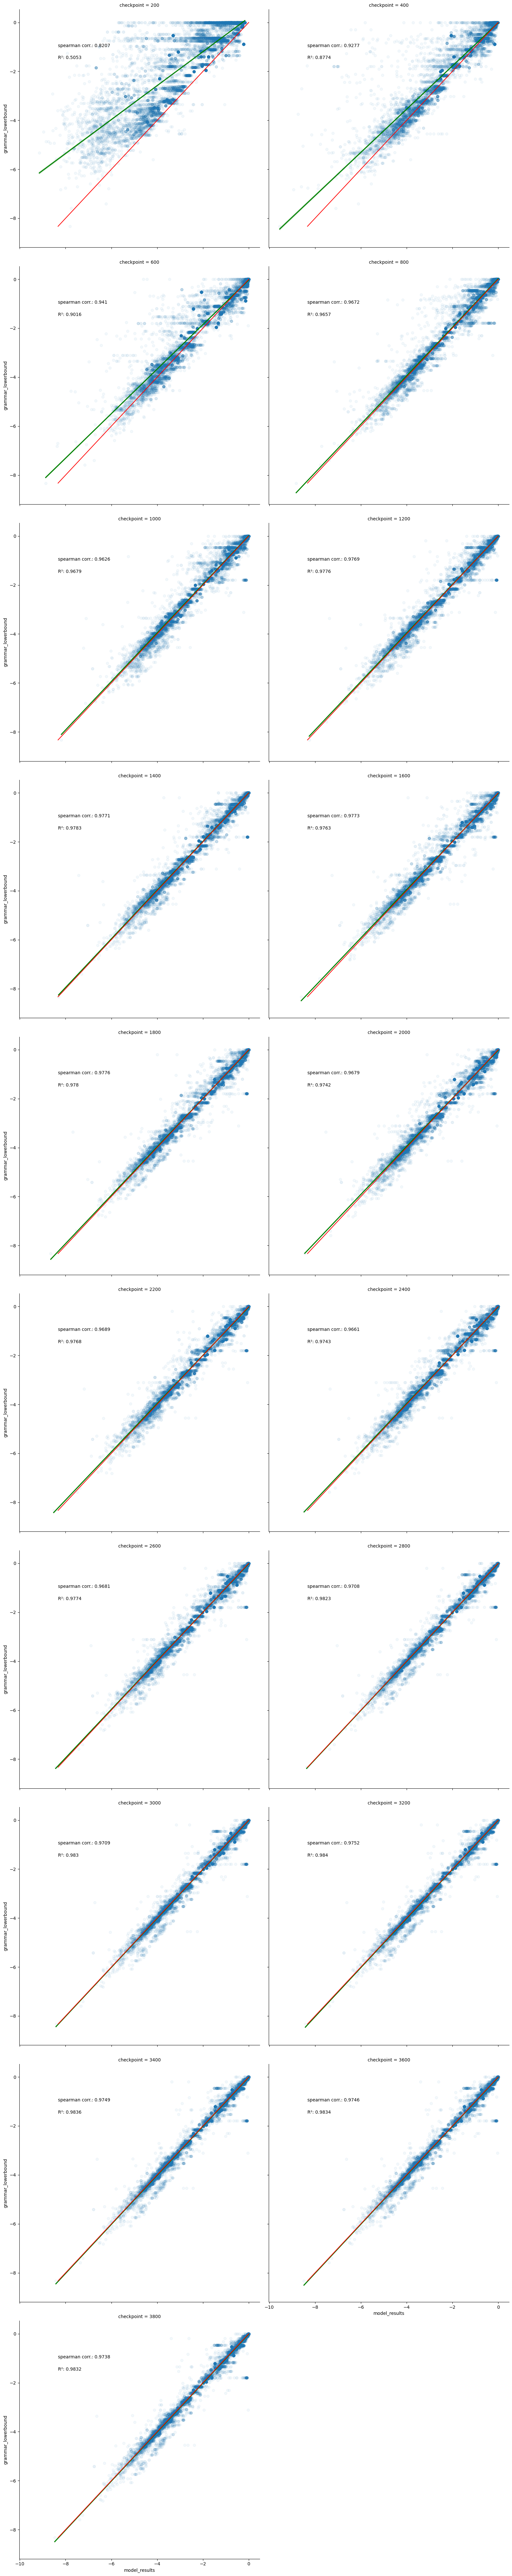

In [18]:
global_axis_vars = axis_vars | dict(col="checkpoint", col_wrap=2)
g = seaborn.lmplot(**global_axis_vars, line_kws={'color': 'g'}, scatter_kws={'alpha': 0.05}, height=8, aspect=1)
for ax in g.axes:
    ax.plot(lims, lims, "-r")
    draw_statistics(**global_axis_vars, ax=ax, lims=lims, facet=True)


In [19]:
#subset = together[(together['grammar_lowerbound'] > -1.8) & (together['grammar_lowerbound'] < -1.79) & (together['model_results'] > -0.9) & (together['checkpoint'] == "1000")]
display(subset)
display(subset.agg(dict(model_results=["min", "max"], grammar_lowerbound=["min", "max"])))
subset = subset[['sent', 'token_pos']]

,sent,model_results,sentence,token,grammar_lowerbound,token_pos,pos,checkpoint
269580,46,-1.051727,46,said,-0.459882,9,VBD,3800
269901,69,-1.353730,69,said,-0.459882,8,VBD,3800
270063,79,-1.341516,79,said,-0.459882,8,VBD,3800
270118,83,-1.209269,83,said,-0.459882,9,VBD,3800
270149,85,-1.321144,85,said,-0.459882,11,VBD,3800
270279,93,-1.319847,93,said,-0.459882,8,VBD,3800
270732,123,-1.366809,123,said,-0.459882,8,VBD,3800
271905,204,-1.466093,204,said,-0.459882,8,VBD,3800
272018,212,-1.415966,212,said,-0.459882,11,VBD,3800
272122,218,-1.209690,218,said,-0.459882,11,VBD,3800


,model_results,grammar_lowerbound
min,-1.516523,-0.459882
max,-1.016006,-0.323995


## by part-of-speech tag

In [20]:
subset['sent'].unique()

array([ 46,  69,  79,  83,  85,  93, 123, 204, 212, 218, 239, 241, 243,
       277, 310, 314, 334, 339, 364, 393, 412, 417, 455, 456, 460, 478,
       481, 574, 586, 590, 597, 625, 627, 628, 630, 661, 670, 703, 707,
       708, 725, 727, 729, 777, 781, 795, 818, 822, 828, 843, 876, 882,
       893, 894, 895, 903, 904, 905, 925, 932])

In [21]:
with pandas.option_context("display.max_colwidth", None): display(together[(together['sent'].isin(subset['sent'].unique())) & (together['checkpoint'] == "3800")].groupby("sent").agg(sentence=pandas.NamedAgg(column="token", aggfunc=lambda g: " ".join(g.to_list()))))

,sentence
sent,
46,"`` I <apostrophe>s a hard friend , <apostrophe><apostrophe> I said , running out on the road ."
69,"`` I think I know , <apostrophe><apostrophe> he said , putting him into the size of the end ."
79,"`` I know I knew , <apostrophe><apostrophe> I said , giving it into the phone ."
83,"`` I know I was doing , <apostrophe><apostrophe> I said , looking on the ground ."
85,"`` I do n<apostrophe>t want to stop it , <apostrophe><apostrophe> he said , running on the corner ."
93,"`` I <apostrophe>ll have done , <apostrophe><apostrophe> he said , telling it on the door ."
123,"`` I <apostrophe>ll be destroyed , <apostrophe><apostrophe> I said , looking out on the room ."
204,"`` I do n<apostrophe>t move , <apostrophe><apostrophe> I said , waving his arm on the window ."
212,"`` I do n<apostrophe>t want to get him , <apostrophe><apostrophe> I said ."


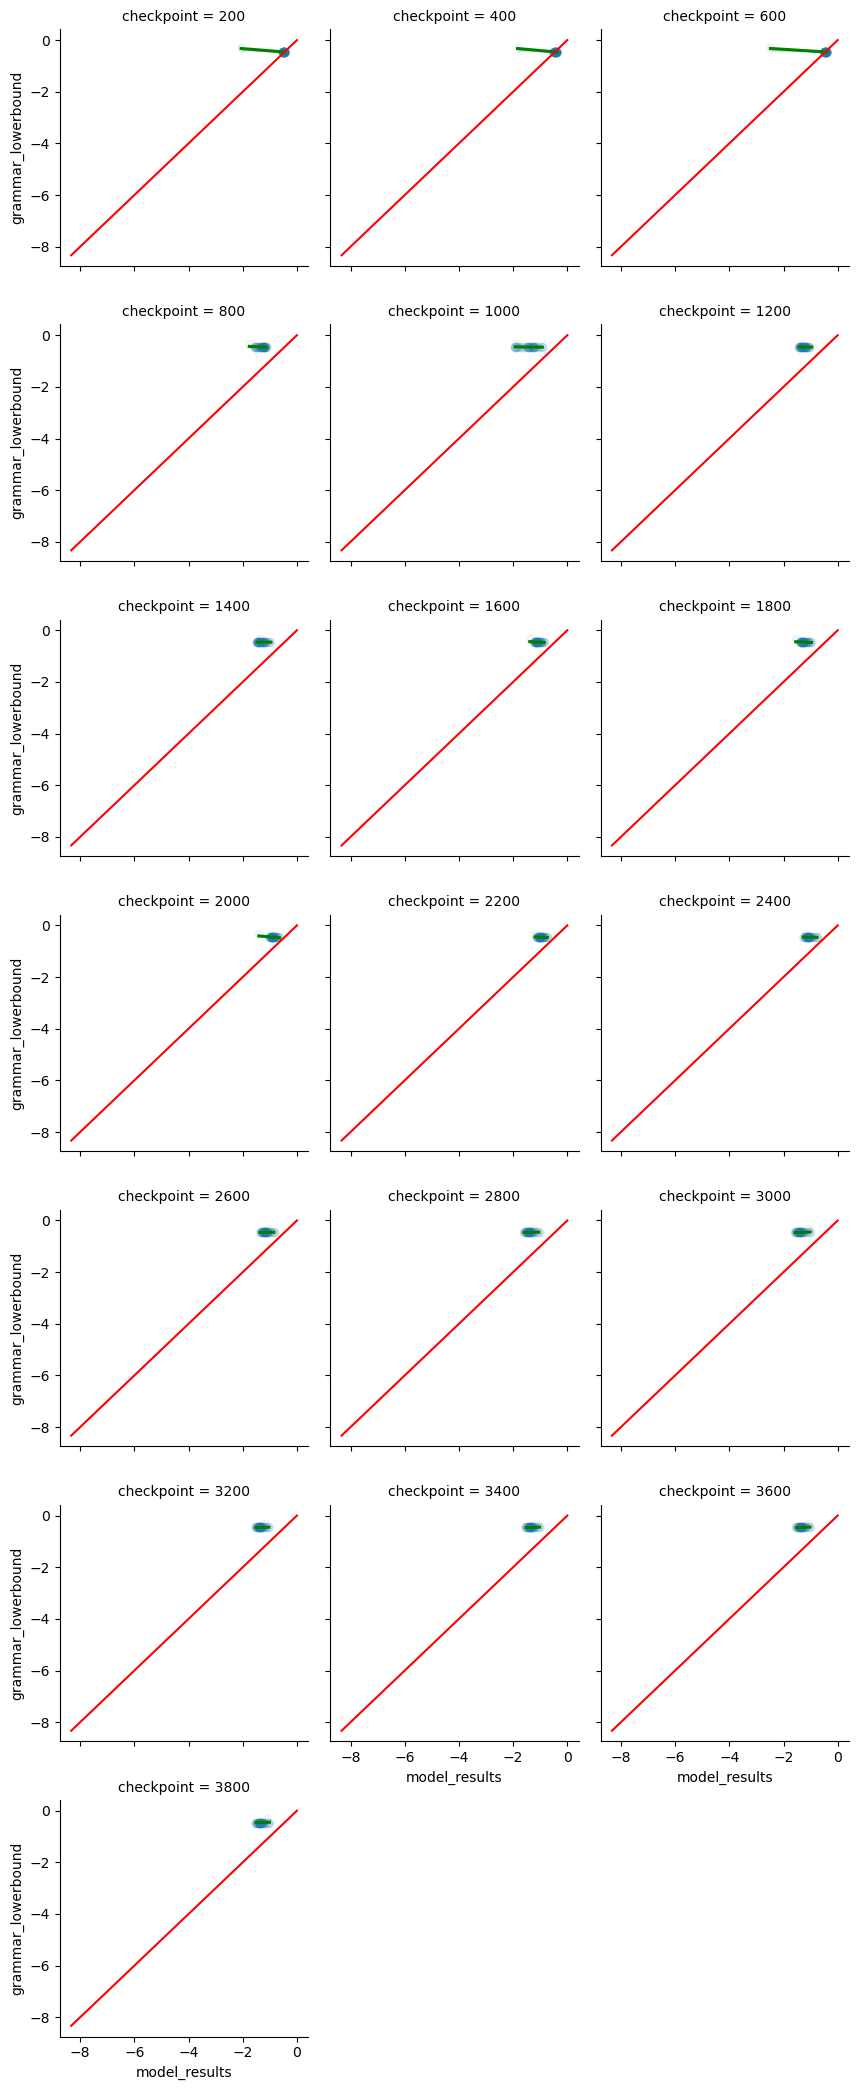

In [22]:
testdf = subset.merge(together, how="left", on=subset.columns.tolist())
global_axis_vars = axis_vars | dict(col="checkpoint", col_wrap=3) | dict(data=testdf)
g = seaborn.lmplot(**global_axis_vars, line_kws={'color': 'g'}, scatter_kws={'alpha': 0.05}, height=3, aspect=1)
for ax in g.axes:
    ax.plot(lims, lims, "-r")
    #draw_statistics(**global_axis_vars, ax=ax, lims=lims, facet=True)